# Load CSV and create a time index (UTC)

In [52]:
import pandas as pd

df = pd.read_csv("../data/raw/smard_pv_realized_hour_2015-2026.csv")

df["time"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True) # Convert Unix timestamps to UTC
df = df.set_index("time") # Set the index to the date/time
df = df.drop(columns="timestamp_ms")

# A brief exploratory analysis of the data
df.head()
print("NaN-Werte:", df.isna().sum())
print(df.index.min(), df.index.max())
print("Duplikate:", df.index.duplicated().sum())
print("Zeilen:", len(df))

NaN-Werte: pv_mw    231
dtype: int64
2014-12-28 23:00:00+00:00 2026-06-21 21:00:00+00:00
Duplikate: 0
Zeilen: 100631


# NaN analysis (to be trimmed later)

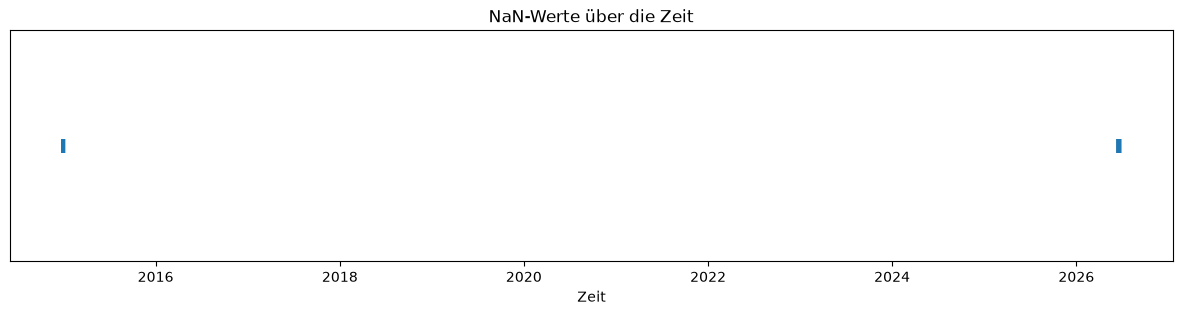

In [53]:
import matplotlib.pyplot as plt

mask = df["pv_mw"].isna()

# Plot when NaN values occurred -> shows only the start date of the recording and the end date when I retrieved the data
plt.figure(figsize=(15, 3))
plt.scatter(
    df.index[mask],
    [1] * mask.sum(),
    marker="|",
    s=100,
)
plt.yticks([])
plt.xlabel("Zeit")
plt.title("NaN-Werte über die Zeit")
plt.show()

In [54]:
valid = df.dropna()

print("Erster gültiger Wert:", valid.index.min())
print("Letzter gültiger Wert:", valid.index.max())

Erster gültiger Wert: 2014-12-31 23:00:00+00:00
Letzter gültiger Wert: 2026-06-15 06:00:00+00:00


# Set start and end dates

In [55]:
# Available of full 11 years
start = pd.Timestamp("2014-12-31 23:00", tz="UTC")
end = pd.Timestamp("2025-12-31 23:00", tz="UTC")
df = df.loc[start:end]

In [56]:
print("NaN nach dem Schnitt:", df["pv_mw"].isna().sum())

NaN nach dem Schnitt: 0


# Distribution of small values

In [57]:
# Check if there are any remaining zero values
print(df["pv_mw"].describe())
print("\nWerte unter 1 MW:", (df["pv_mw"] < 1).sum())
print("Exakte Nullen:", (df["pv_mw"] == 0).sum())
print("Negative Werte:", (df["pv_mw"] < 0).sum())

count    96433.000000
mean      5481.885211
std       8719.514265
min          0.000000
25%          0.840000
50%        160.350000
75%       8452.590000
max      52132.250000
Name: pv_mw, dtype: float64

Werte unter 1 MW: 24330
Exakte Nullen: 7770
Negative Werte: 0


In [58]:
zeros = df[df["pv_mw"] == 0]

# At what UTC hour do the exact zeros occur?
print(zeros.index.hour.value_counts().sort_index())

# Is the maximum value real?
print(df["pv_mw"].idxmax(), df["pv_mw"].max())

time
0     830
1     793
2     635
3     459
4     308
5     204
6      26
16     31
17    238
18    385
19    541
20    751
21    859
22    868
23    842
Name: count, dtype: int64
2025-06-20 10:00:00+00:00 52132.25


<Axes: title={'center': 'Tagesgang 21.06.2020'}, xlabel='time'>

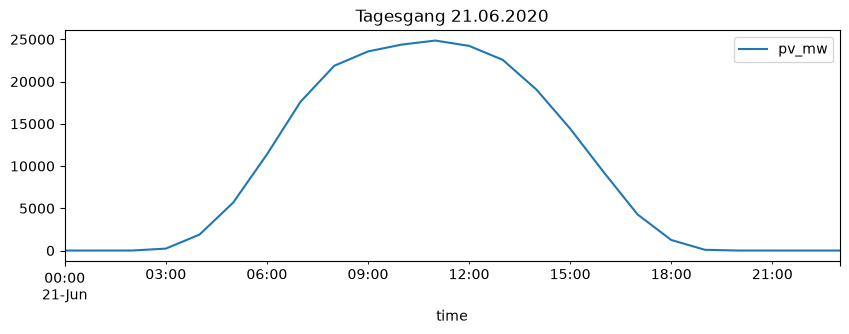

In [59]:
# Plotting a random date (my birthday, lol)
df.loc["2025-09-04"].plot(figsize=(10, 3), title="Tagesgang 04.09.2025")

# Save the cleaned-up table

In [ ]:
from pvforecast.config import PROCESSED_DIR

# Save the processed file as parquet
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_parquet(PROCESSED_DIR / "pv_hourly.parquet")

check = pd.read_parquet(PROCESSED_DIR / "pv_hourly.parquet")
print(check.index.dtype)
print(check.shape)